# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 50    |  |
| :-------------|:-------------|
| Avnay Taneja| 5938724 |
| Student naam 2| Student Studienummer 2 |
| Student naam 3| Student Studienummer 3 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Avnay', 'Koen']#,'Aren'] #Aren is niet meegenomen in de metingen omdat we maar 2 van de 3 algoritmes hebben gedaan

## Opdracht 1: Planning.

| Planning Groep: 50    |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren sensor | 11:30 |
| Testen meetopstelling | 12:00 |
| Ontwerp individueel algoritme | 14:00 |
| Iteratie 0 | 15:00 |
| Iteratie 1 | 15:45 |
| Pauze 1| 11:45-12:00 |
| Pauze 2| 15:00-15:15|

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [50]
<img src="kalibratie_sensor.jpeg" width="400">

0.03376490833376811 -0.9603909503342103


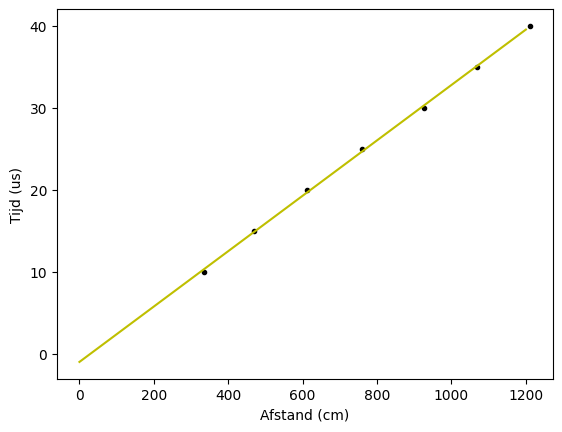

In [3]:
afstanden = np.array([10,15,20,25,30,35,40]) #cm
tijden = np.array([334,470,612,760,926,1068,1212]) #us #+-4 us

def linear_model(x,a,b):
    return x*a + b

val,cov = curve_fit(linear_model,tijden, afstanden)
a,b = val

x_fit = np.linspace(0, 1200 ,1000)
y_fit = linear_model(x_fit, *val)

plt.figure
plt.plot(tijden, afstanden, 'k.')
plt.plot(x_fit,y_fit,"y")
plt.xlabel("Afstand (cm)")
plt.ylabel("Tijd (us)")
plt.show

print(a,b)

## Opdracht 4: Test meting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  43.2
1   0  30   0  20  42.5
2   0  10   0  20  46.5
3  40   0  30   0  42.3
4  30   0  20   0  42.4
5  10   0  20   0  47.6


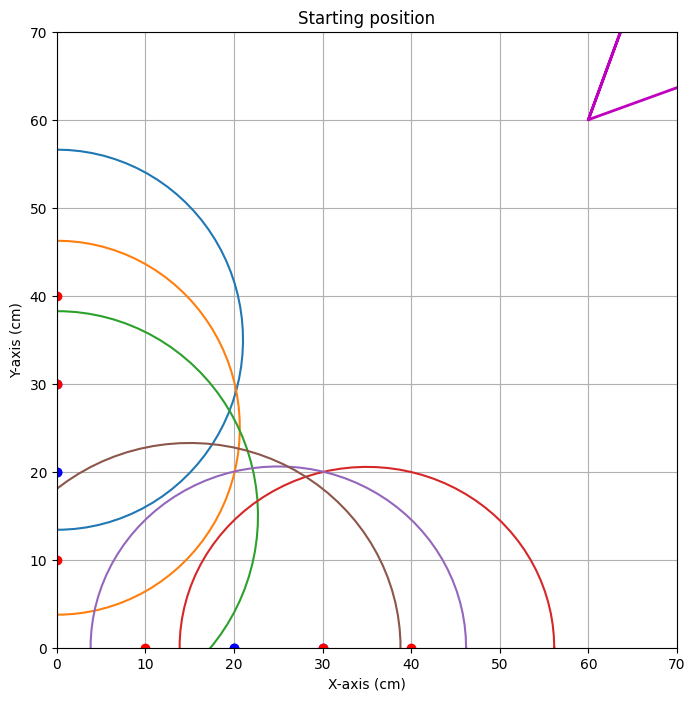


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=103.141
end iteration 2 with average mismatch=97.064


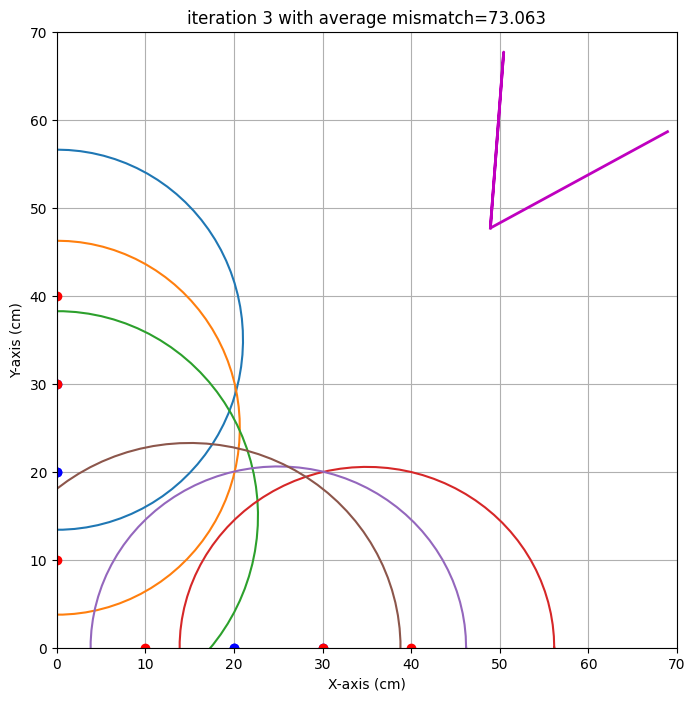

end iteration 3 with average mismatch=73.063


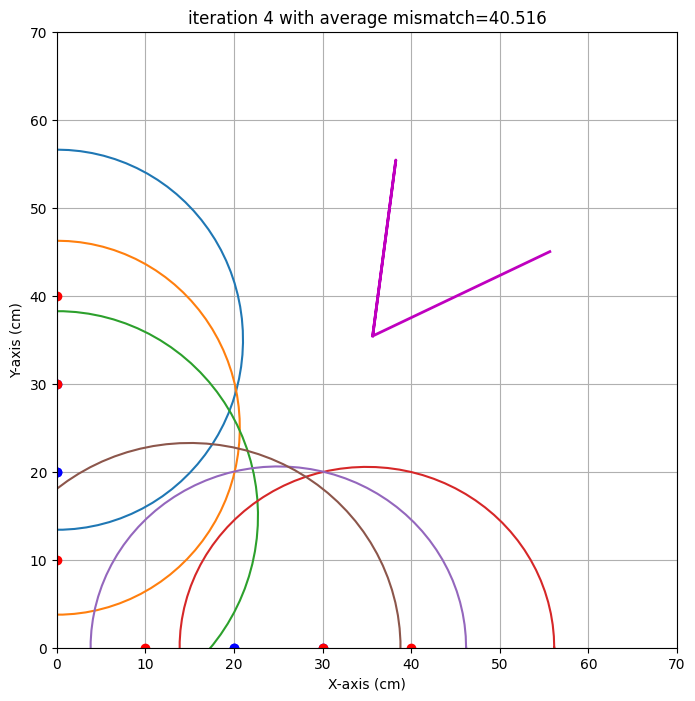

end iteration 4 with average mismatch=40.516


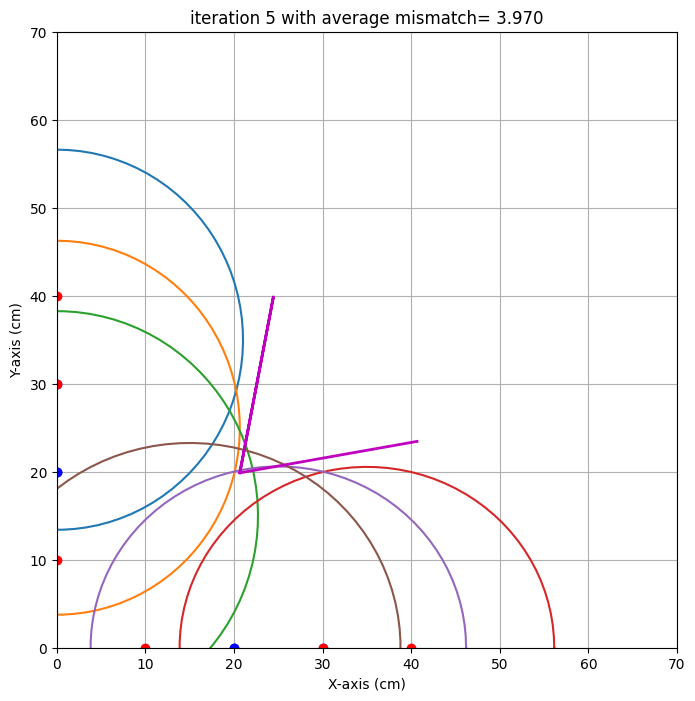

end iteration 5 with average mismatch= 3.970


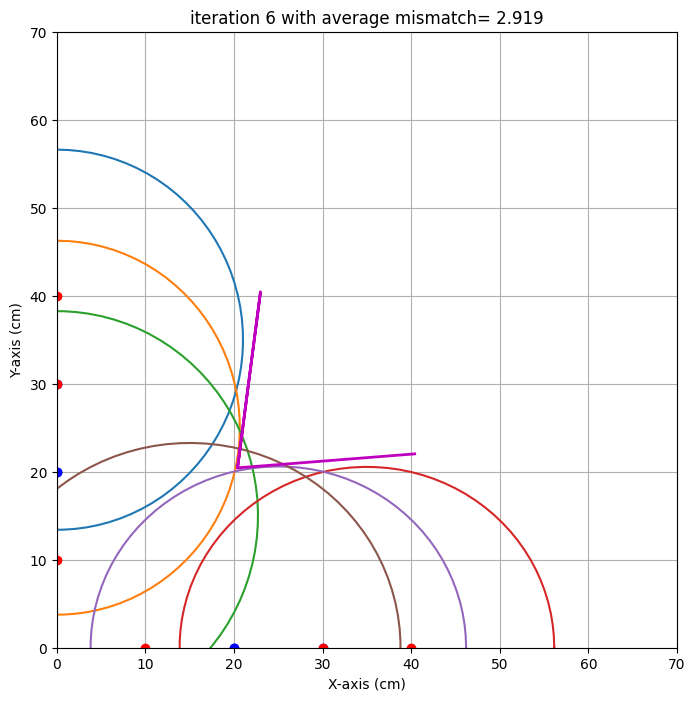

end iteration 6 with average mismatch= 2.919


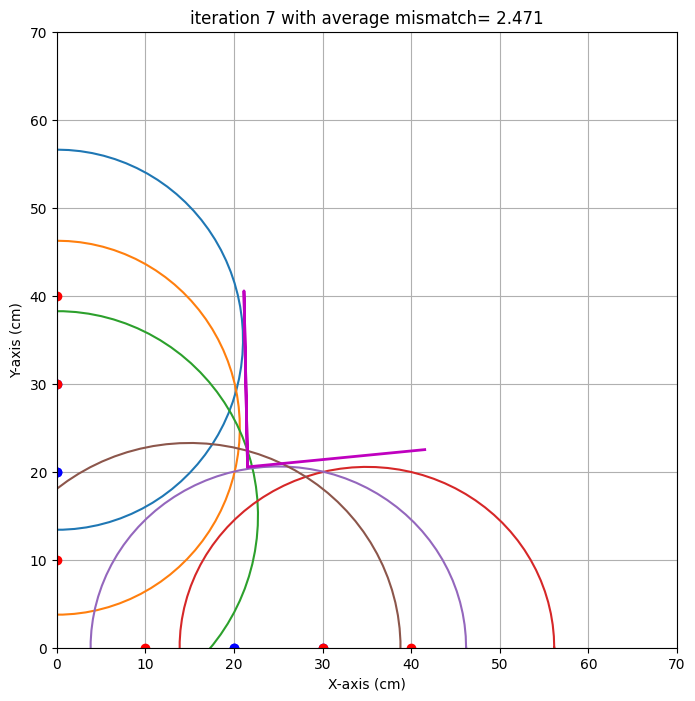

end iteration 7 with average mismatch= 2.471


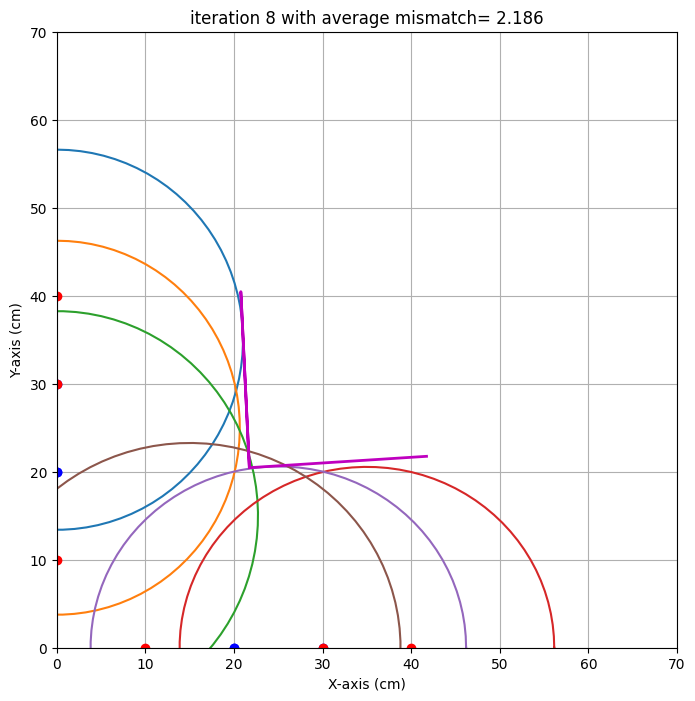

end iteration 8 with average mismatch= 2.186
end iteration 9 with average mismatch= 2.140
end iteration 10 with average mismatch= 1.964
end iteration 11 with average mismatch= 1.921
end iteration 12 with average mismatch= 1.861
end iteration 13 with average mismatch= 1.842
end iteration 14 with average mismatch= 1.826
end iteration 15 with average mismatch= 1.826
end iteration 16 with average mismatch= 1.826
end iteration 17 with average mismatch= 1.826
end iteration 18 with average mismatch= 1.826
end iteration 19 with average mismatch= 1.826
end iteration 20 with average mismatch= 1.826
end iteration 21 with average mismatch= 1.767
end iteration 22 with average mismatch= 1.758
end iteration 23 with average mismatch= 1.758
end iteration 24 with average mismatch= 1.758
end iteration 25 with average mismatch= 1.758
end iteration 26 with average mismatch= 1.758
end iteration 27 with average mismatch= 1.758
end iteration 28 with average mismatch= 1.758
end iteration 29 with average mismat

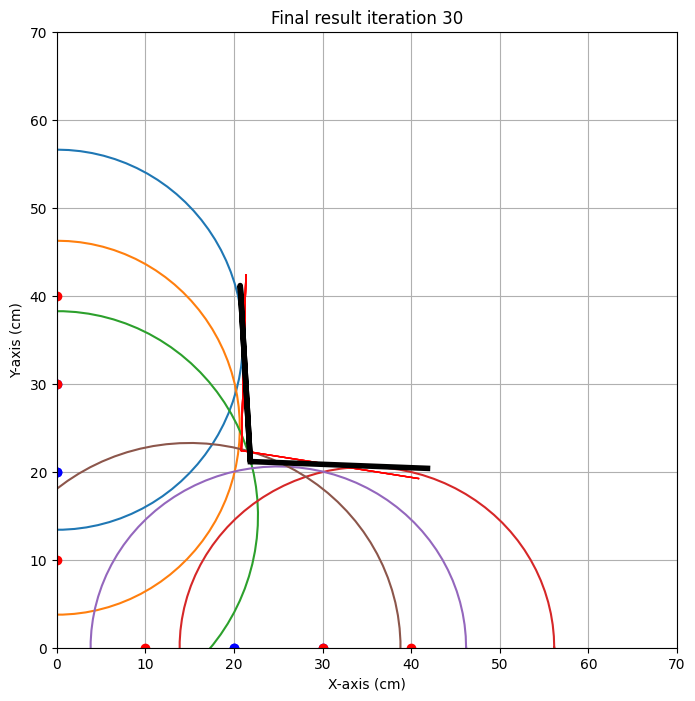

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,43.2],
    [0,30,0,20,42.5],
    [0,10,0,20,46.5],
    [40,0,30,0,42.3],
    [30,0,20,0,42.4],
    [10,0,20,0,47.6],
    #[10,0,0,10,180.3]    #deze meting is niet geldig
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.8 cm met een standaardafwijking van 1.0 cm 
y0: 21.2 cm met een standaardafwijking van 1.2 cm 
alpha: -2.2 graden met een standaardafwijking van 6.8 graad 
beta: -3.3 graden met een standaardafwijking van 4.7 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Avnay]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="algoritme_avnay_1.jpeg" width="400">
<img src="algoritme_avnay_2.jpeg" width="400">

#### algoritme [Aren]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="algoritme_aren_2.jpeg" width="400">

#### algoritme [Koen]
Voeg een foto in van het algoritme van het derde groepslid
<img src="algoritme_koen_1.jpeg" width="400">
<img src="algoritme_koen_2.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets1 = {'x0': 26,
           'y0': 37,
           'alpha' : 32,
           'beta' : 8,
          }
           
targets2 = {'x0': 39,
           'y0': 25,
           'alpha' : 22 ,
           'beta' : 6,
          }         

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Avnay' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,50,0,60,64.5],
    [0,40,0,50,61.9],
    #[0,30,0,40,ongeldig]
    #[50,0,60,0,ongeldig]
    [40,0,50,0,76.3],
    [30,0,40,0,65.1]
    #[20,0,30,0,ongeldig]
    ]),
        'Koen' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,60,0,40,83.0],
    [0,40,0,20,81.3],
    [60,0,40,0,62.2],
    #[40,0,20,0,ongeldig]
    [0,45,0,55,78.5],
    [0,25,0,35,75.0],
    [45,0,55,0,58.6]
     ])
      }

## Opdracht 7: Evaluatie.

Avnay
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  50   0  60  64.5
1   0  40   0  50  61.9
2  40   0  50   0  76.3
3  30   0  40   0  65.1


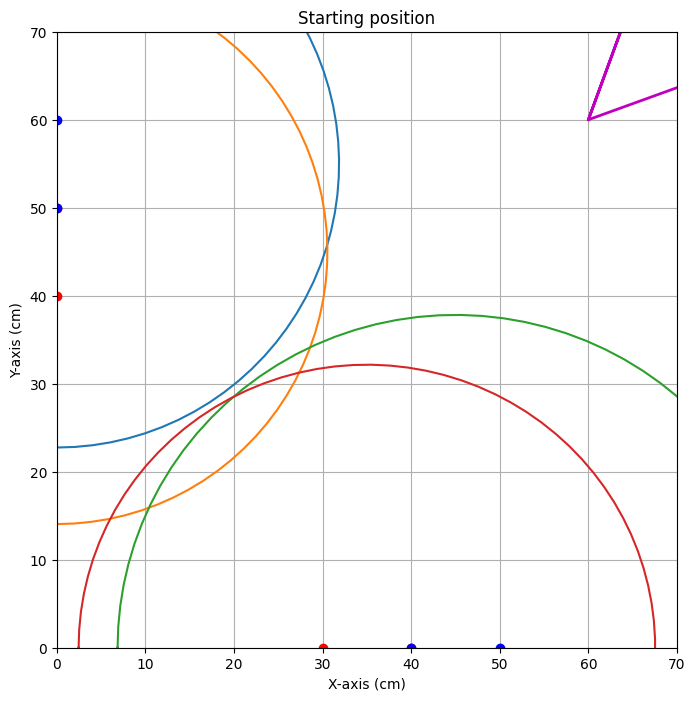


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=63.966


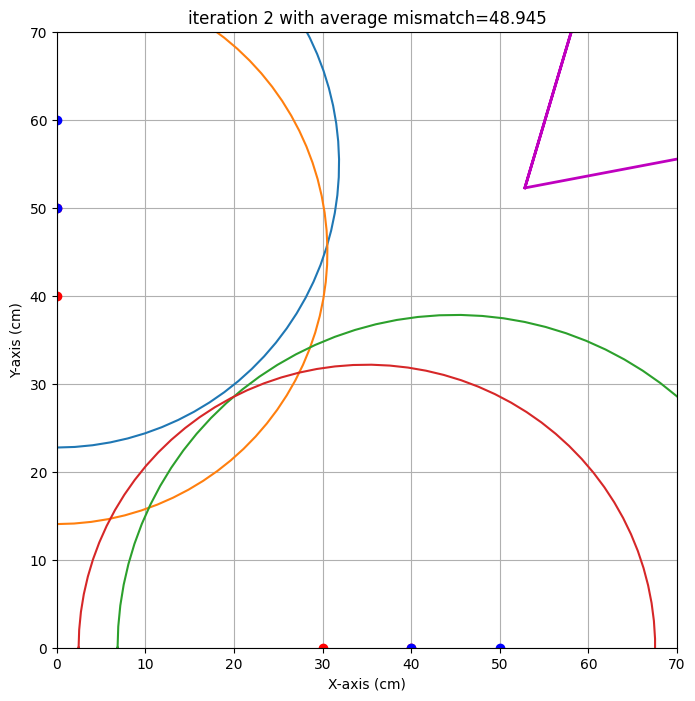

end iteration 2 with average mismatch=48.945


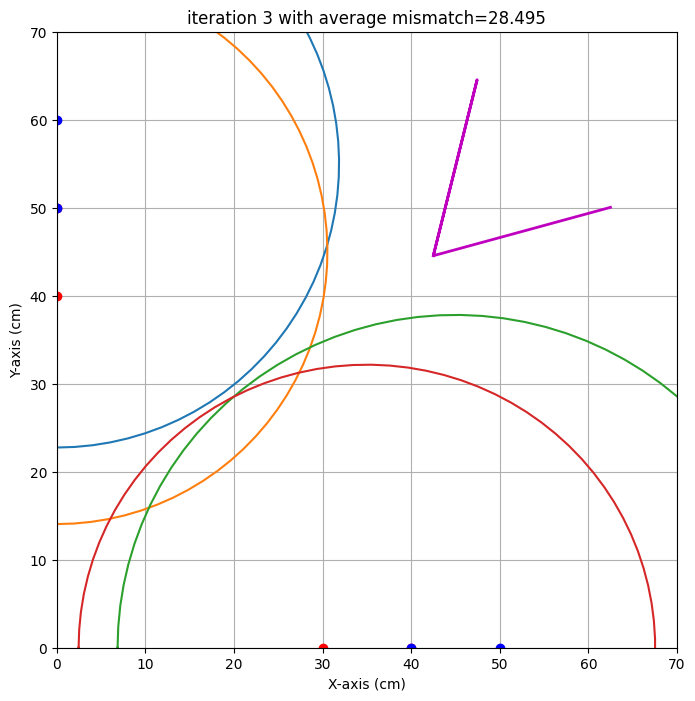

end iteration 3 with average mismatch=28.495


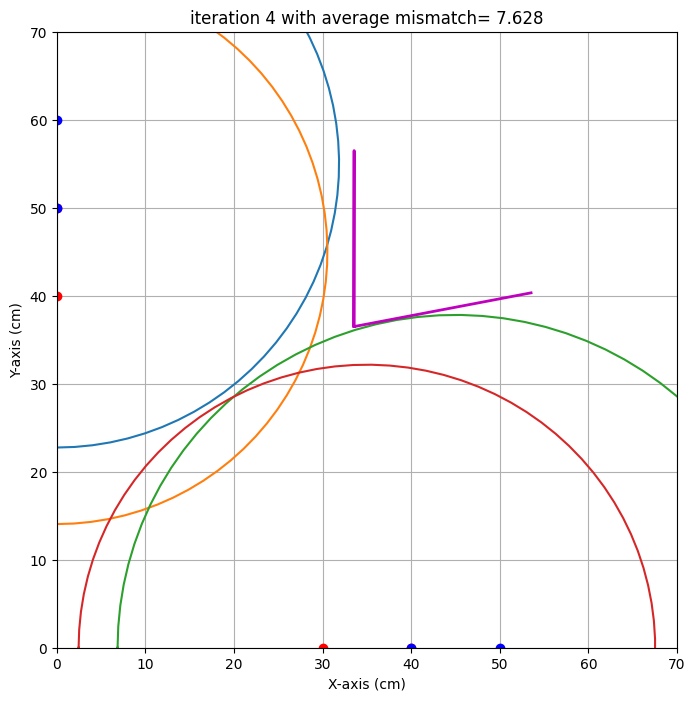

end iteration 4 with average mismatch= 7.628


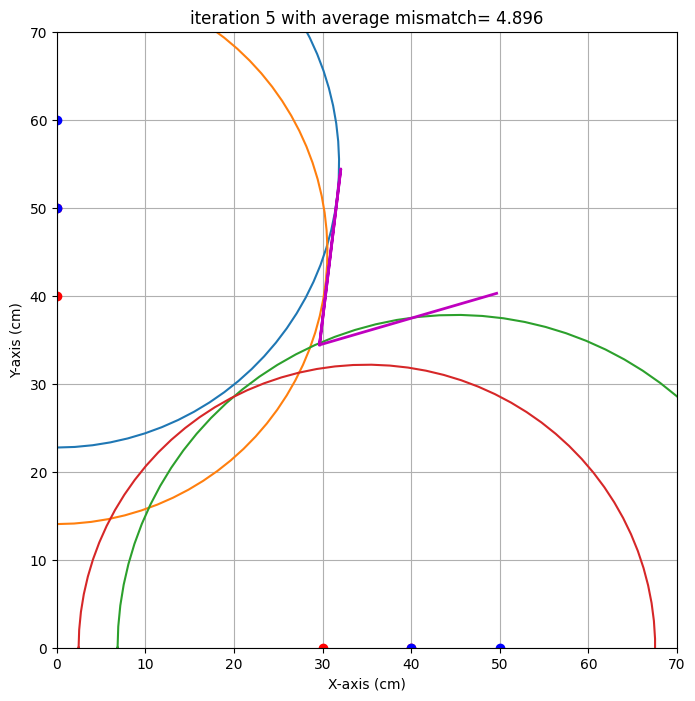

end iteration 5 with average mismatch= 4.896
end iteration 6 with average mismatch= 4.610
end iteration 7 with average mismatch= 4.580
end iteration 8 with average mismatch= 4.575
end iteration 9 with average mismatch= 4.572
end iteration 10 with average mismatch= 4.572
end iteration 11 with average mismatch= 4.571
end iteration 12 with average mismatch= 4.571
end iteration 13 with average mismatch= 4.456
end iteration 14 with average mismatch= 4.455
end iteration 15 with average mismatch= 4.455
end iteration 16 with average mismatch= 4.455
end iteration 17 with average mismatch= 4.454
end iteration 18 with average mismatch= 4.452
end iteration 19 with average mismatch= 4.448
end iteration 20 with average mismatch= 4.440
end iteration 21 with average mismatch= 4.433
end iteration 22 with average mismatch= 4.433
end iteration 23 with average mismatch= 4.433
end iteration 24 with average mismatch= 4.433
end iteration 25 with average mismatch= 4.433
end iteration 26 with average mismatch=

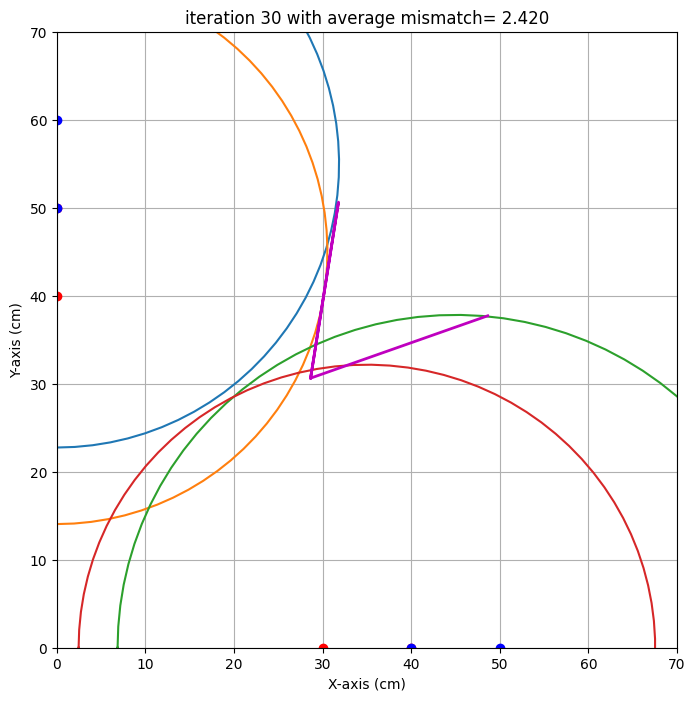

end iteration 30 with average mismatch= 2.420
###############################################################################
end of iteration  30
Best alpha=  19.51 with uncertainty=  13.75
Best beta =   8.95 with uncertainty=   5.59
Best x0   =  28.64 with uncertainty=   1.47
Best y0   =  30.63 with uncertainty=   4.26
###############################################################################


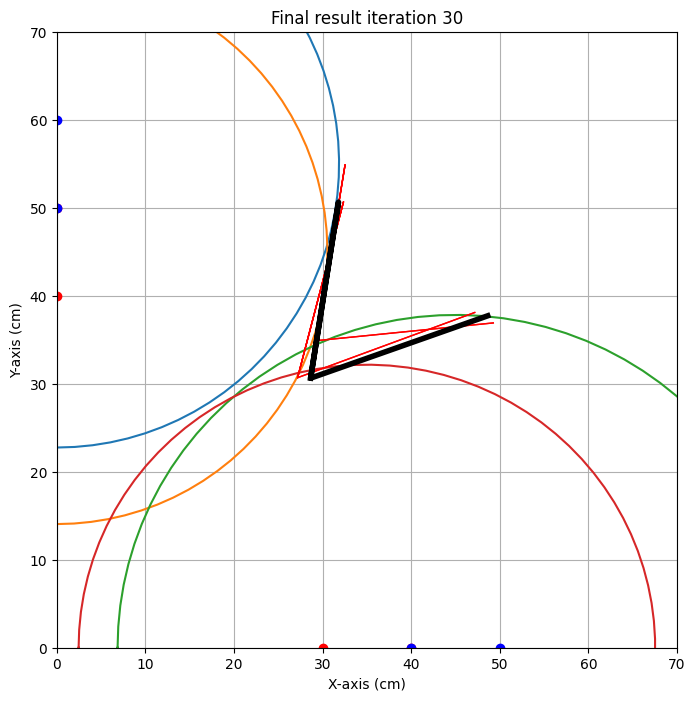

{'alpha': np.float64(19.50829883931409), 'alpha_eps': np.float64(13.745799038891088), 'beta': np.float64(8.951363660522247), 'beta_eps': np.float64(5.593434653947167), 'x0': np.float64(28.641152522976967), 'x0_eps': np.float64(1.4673611606582924), 'y0': np.float64(30.63316191643607), 'y0_eps': np.float64(4.25745106051227)}
Koen
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  60   0  40  83.0
1   0  40   0  20  81.3
2  60   0  40   0  62.2
3   0  45   0  55  78.5
4   0  25   0  35  75.0
5  45   0  55   0  58.6


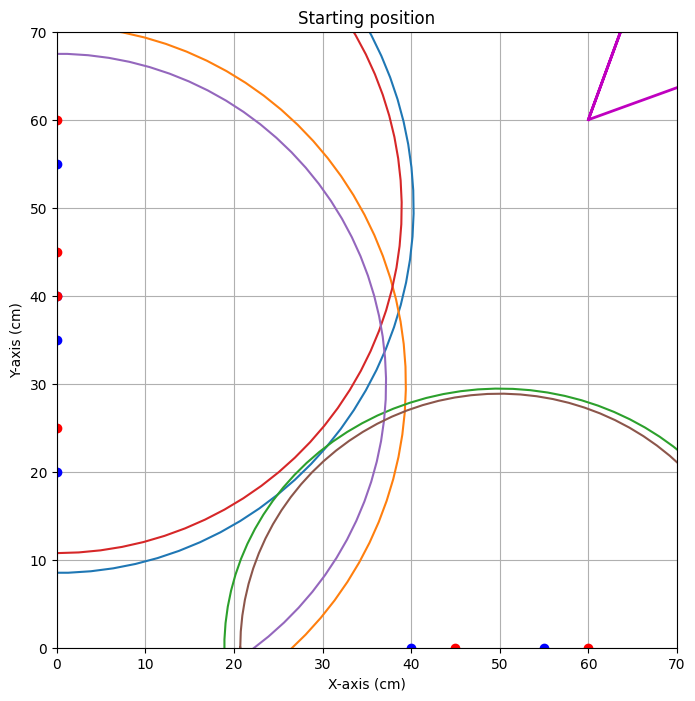


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=59.527


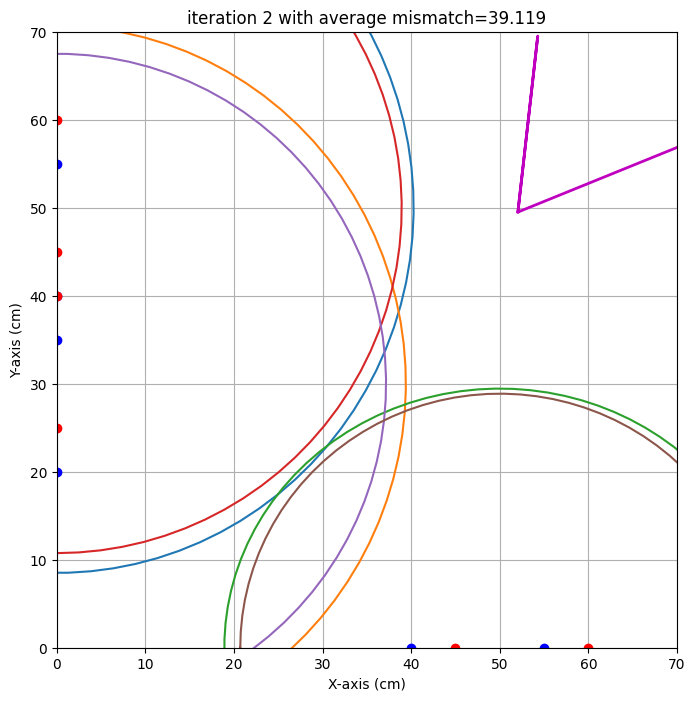

end iteration 2 with average mismatch=39.119


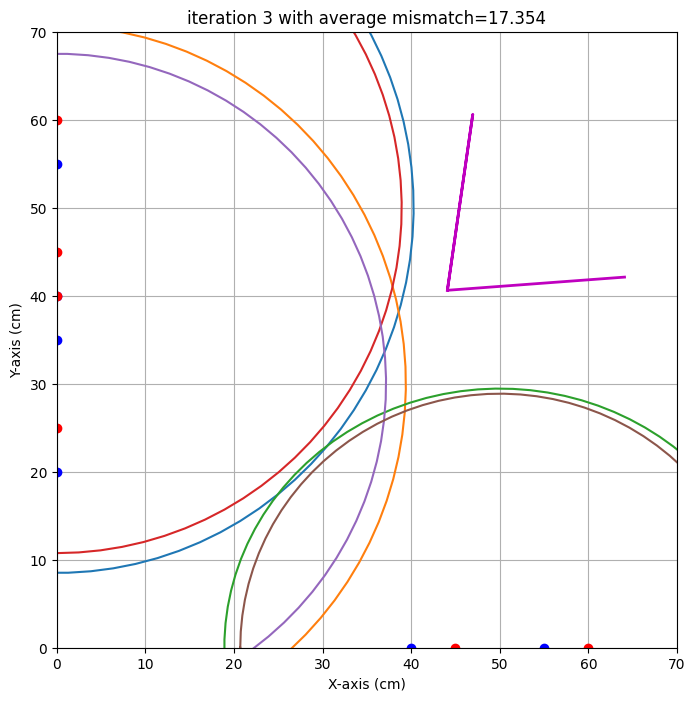

end iteration 3 with average mismatch=17.354


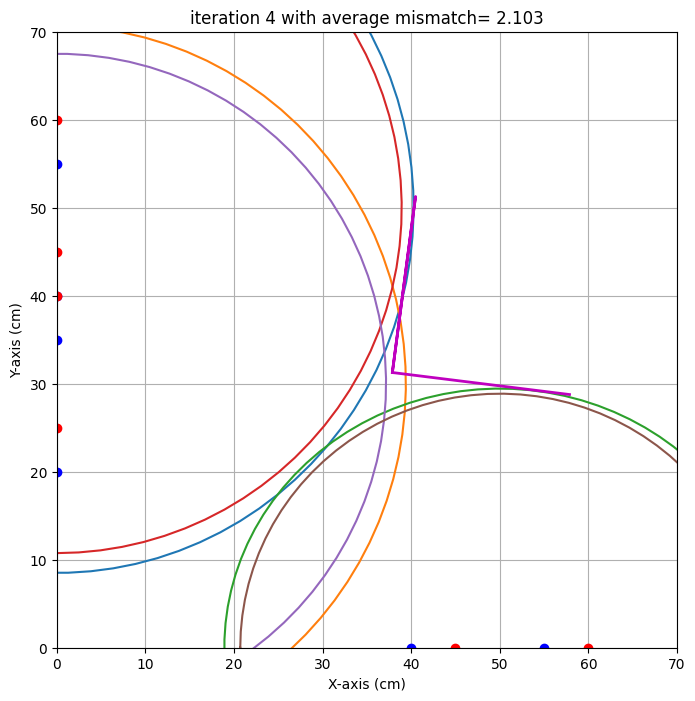

end iteration 4 with average mismatch= 2.103


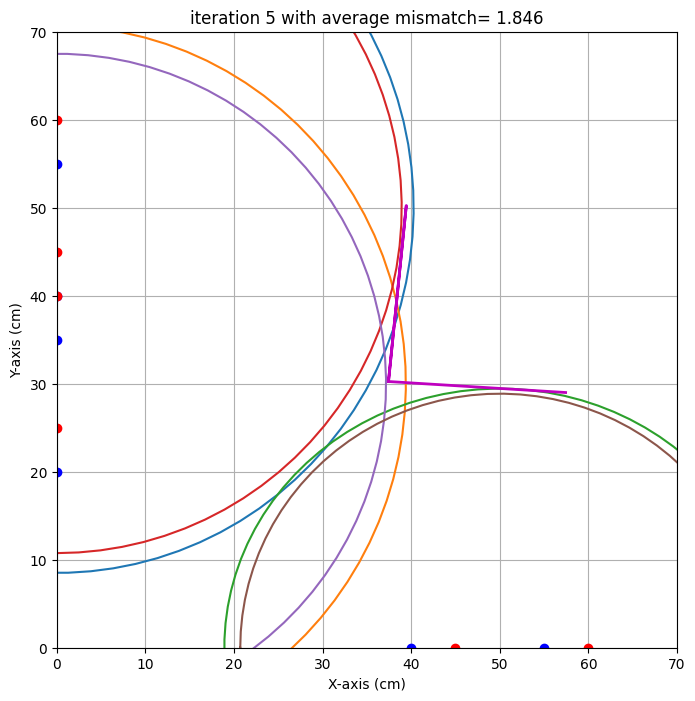

end iteration 5 with average mismatch= 1.846
end iteration 6 with average mismatch= 1.805
end iteration 7 with average mismatch= 1.766
end iteration 8 with average mismatch= 1.766
end iteration 9 with average mismatch= 1.719
end iteration 10 with average mismatch= 1.641
end iteration 11 with average mismatch= 1.638
end iteration 12 with average mismatch= 1.636
end iteration 13 with average mismatch= 1.636
end iteration 14 with average mismatch= 1.636
end iteration 15 with average mismatch= 1.636
end iteration 16 with average mismatch= 1.636
end iteration 17 with average mismatch= 1.636
end iteration 18 with average mismatch= 1.636
end iteration 19 with average mismatch= 1.625
end iteration 20 with average mismatch= 1.603
end iteration 21 with average mismatch= 1.595
end iteration 22 with average mismatch= 1.595
end iteration 23 with average mismatch= 1.595
end iteration 24 with average mismatch= 1.595
end iteration 25 with average mismatch= 1.595
end iteration 26 with average mismatch=

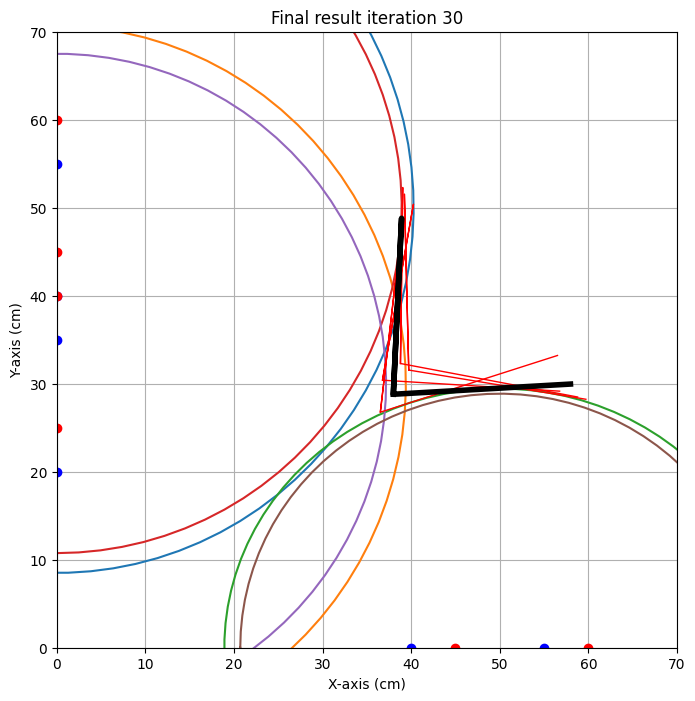

{'alpha': np.float64(3.314678691253685), 'alpha_eps': np.float64(14.542716980438492), 'beta': np.float64(2.6683705815462573), 'beta_eps': np.float64(7.251410522358647), 'x0': np.float64(37.982273129176086), 'x0_eps': np.float64(1.7411890684287243), 'y0': np.float64(28.80240545669224), 'y0_eps': np.float64(3.4960656912528236)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName[0:5],
                     x0Target=targets1['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets1['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets1['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets1['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))
    print(txt.format(naam = studentName[5:9],
                     x0Target=targets2['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets2['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets2['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets2['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))
    
    

Avnay 
x0 target is : 26.0. Gevonden waarde: 28.6 cm met een standaardafwijking van 1.5 cm 
y0 target is : 37.0. Gevonden waarde: 30.6 cm met een standaardafwijking van 4.3 cm 
alpha target is : 32.0. Gevonden waarde: 19.5 graden met een standaardafwijking van 13.7 graad 
beta target is : 8.0. Gevonden waarde: 9.0 graden met een standaardafwijking van 5.6 graad 

 
x0 target is : 39.0. Gevonden waarde: 28.6 cm met een standaardafwijking van 1.5 cm 
y0 target is : 25.0. Gevonden waarde: 30.6 cm met een standaardafwijking van 4.3 cm 
alpha target is : 22.0. Gevonden waarde: 19.5 graden met een standaardafwijking van 13.7 graad 
beta target is : 6.0. Gevonden waarde: 9.0 graden met een standaardafwijking van 5.6 graad 

Koen 
x0 target is : 26.0. Gevonden waarde: 38.0 cm met een standaardafwijking van 1.7 cm 
y0 target is : 37.0. Gevonden waarde: 28.8 cm met een standaardafwijking van 3.5 cm 
alpha target is : 32.0. Gevonden waarde: 3.3 graden met een standaardafwijking van 14.5 graad 
be

## Opdracht 8: Iteratie1+.15:45
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](iteratie1.jpeg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  60   68.5
1  40   0  60   0  100.7
2  45   0  55   0   99.8
3   0  45   0  55   64.2
4   0  55   0  65   64.3
5   0  60   0  70   66.1
6  35   0  45   0  122.0
7  50   0  60   0  106.8


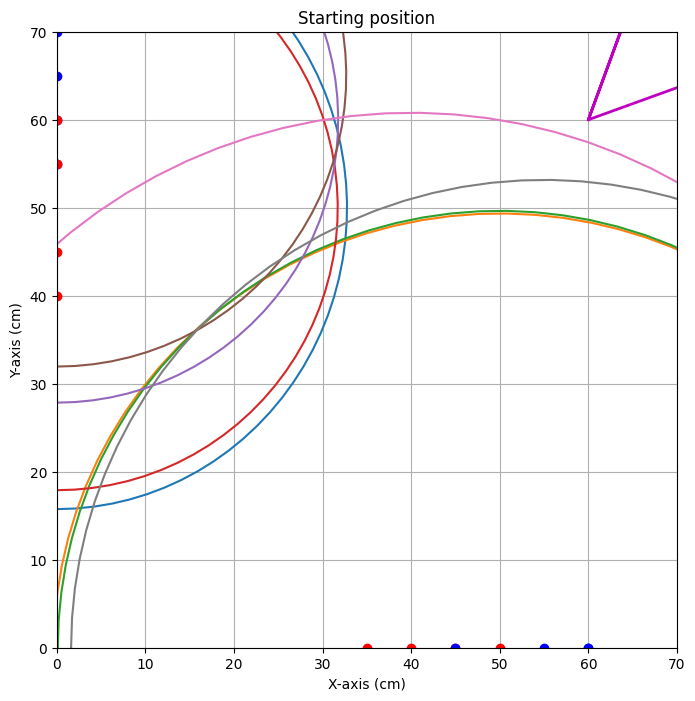


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=41.533


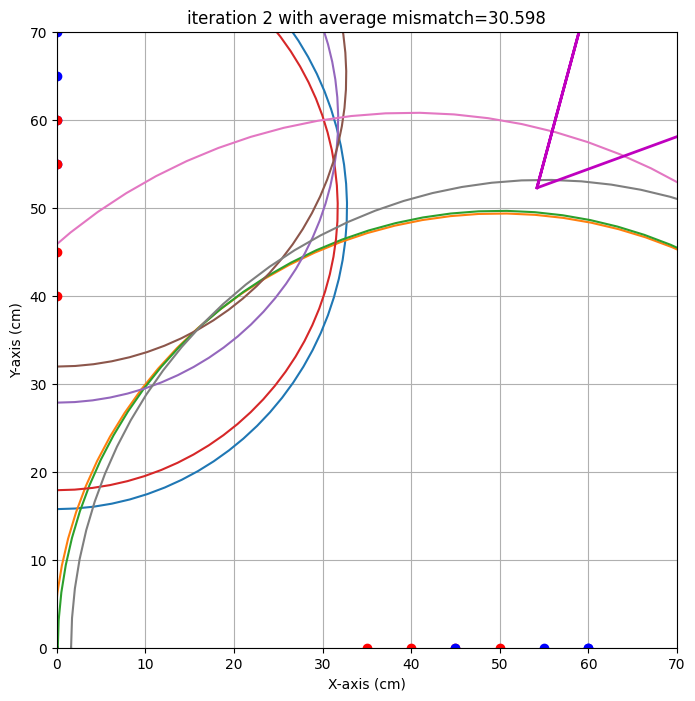

end iteration 2 with average mismatch=30.598


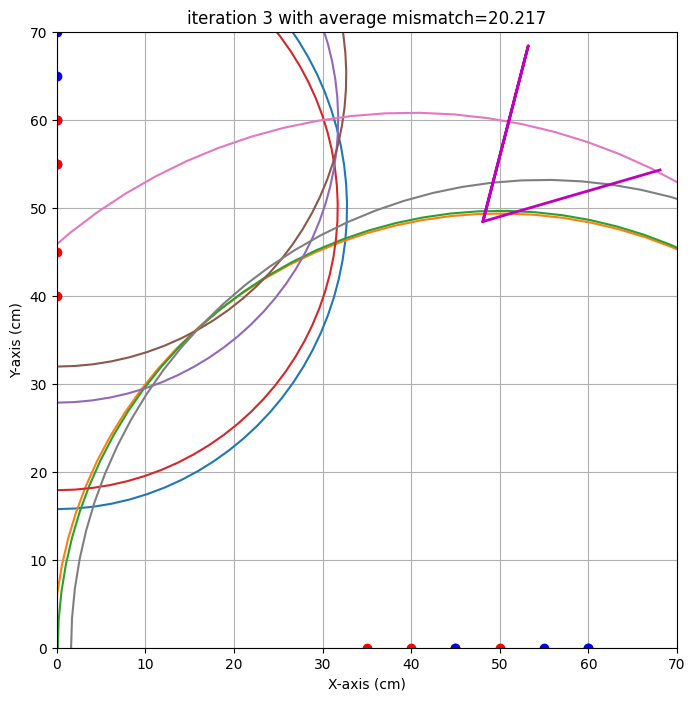

end iteration 3 with average mismatch=20.217


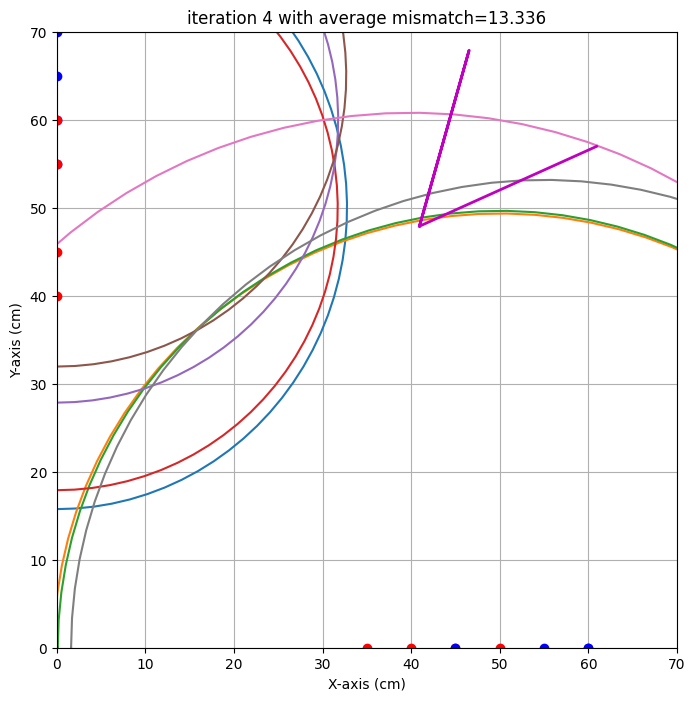

end iteration 4 with average mismatch=13.336


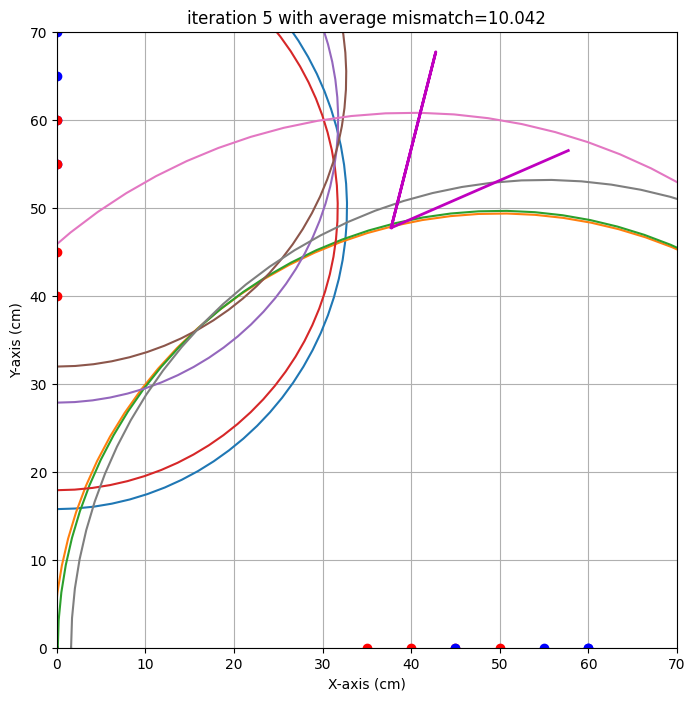

end iteration 5 with average mismatch=10.042


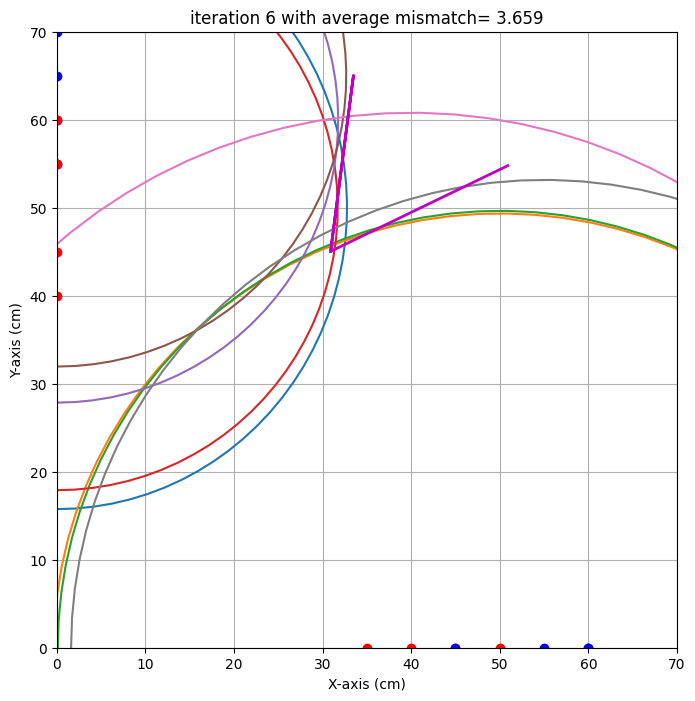

end iteration 6 with average mismatch= 3.659


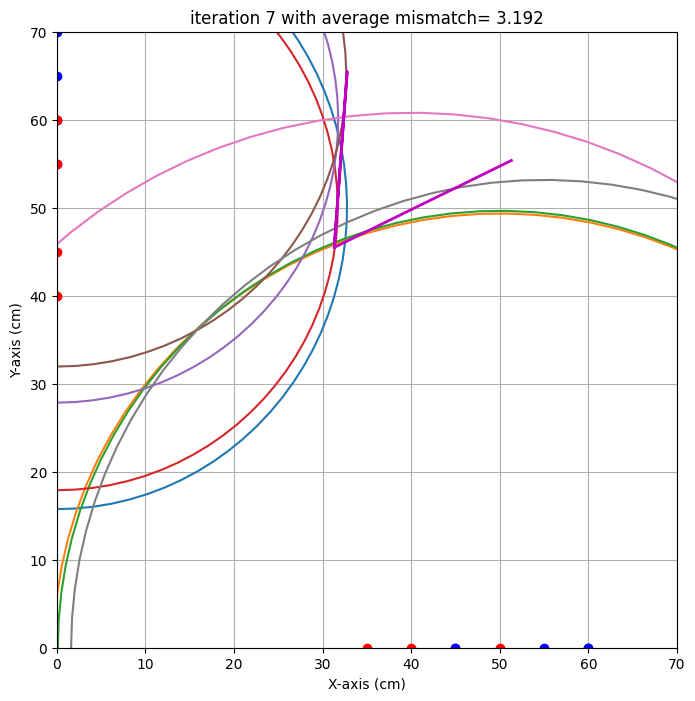

end iteration 7 with average mismatch= 3.192
end iteration 8 with average mismatch= 3.069
end iteration 9 with average mismatch= 3.069
end iteration 10 with average mismatch= 2.870
end iteration 11 with average mismatch= 2.806
end iteration 12 with average mismatch= 2.601
end iteration 13 with average mismatch= 2.601
end iteration 14 with average mismatch= 2.601
end iteration 15 with average mismatch= 2.601
end iteration 16 with average mismatch= 2.601
end iteration 17 with average mismatch= 2.601
end iteration 18 with average mismatch= 2.601
end iteration 19 with average mismatch= 2.601
end iteration 20 with average mismatch= 2.601
end iteration 21 with average mismatch= 2.601
end iteration 22 with average mismatch= 2.575
end iteration 23 with average mismatch= 2.575
end iteration 24 with average mismatch= 2.575
end iteration 25 with average mismatch= 2.575
end iteration 26 with average mismatch= 2.575
end iteration 27 with average mismatch= 2.574
end iteration 28 with average mismatc

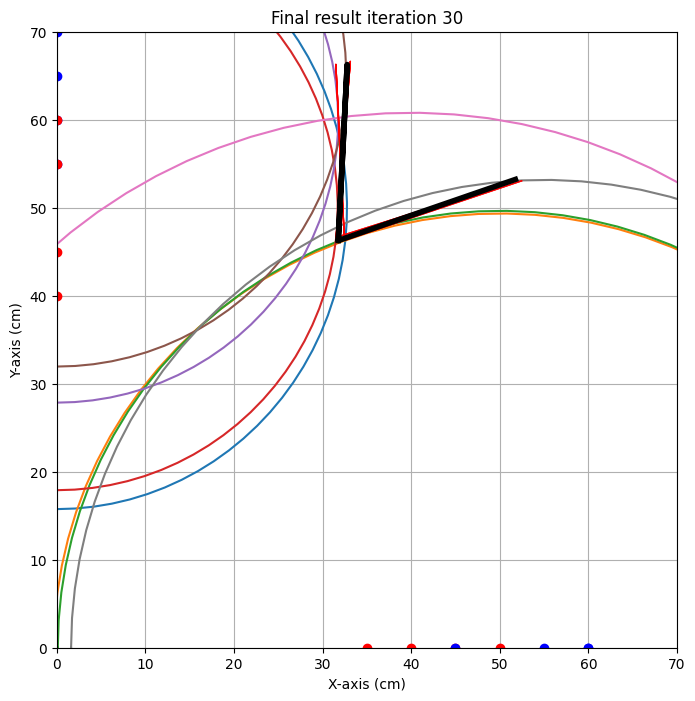

{'alpha': np.float64(19.14475078916605), 'alpha_eps': np.float64(1.4779862209591421), 'beta': np.float64(2.895915526400504), 'beta_eps': np.float64(5.672900374910566), 'x0': np.float64(31.763614306883927), 'x0_eps': np.float64(0.701446203081975), 'y0': np.float64(46.27114109896507), 'y0_eps': np.float64(0.362380531757843)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  20   0  40  91.5
1  40   0  60   0  46.9
2   0  35   0  45  92.1
3   0  25   0  35  89.8
4  55   0  65   0  43.6
5  45   0  55   0  39.4
6  60   0  70   0  44.7
7   0  35   0  41  92.3


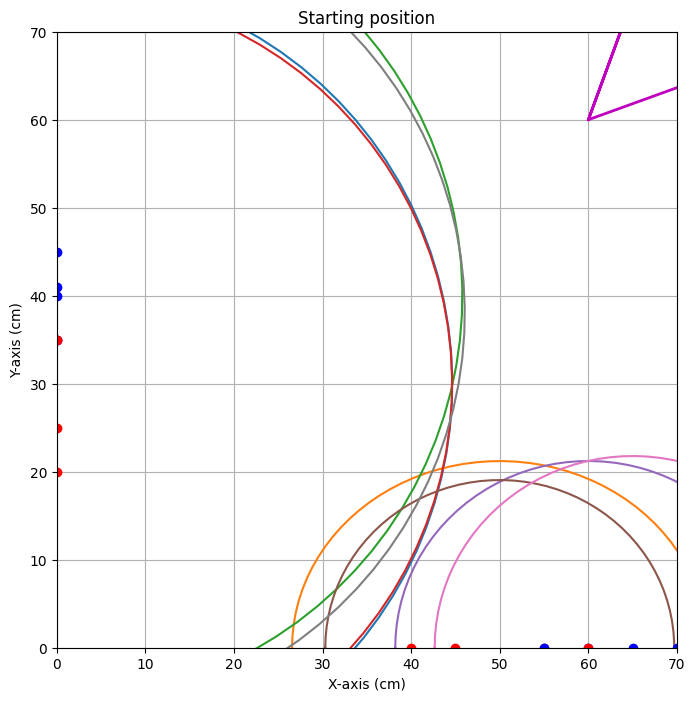


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=65.843


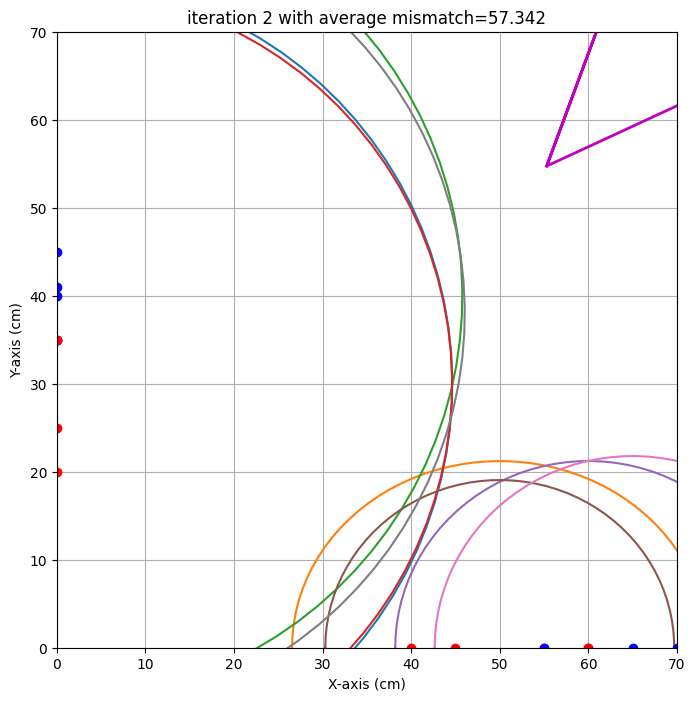

end iteration 2 with average mismatch=57.342


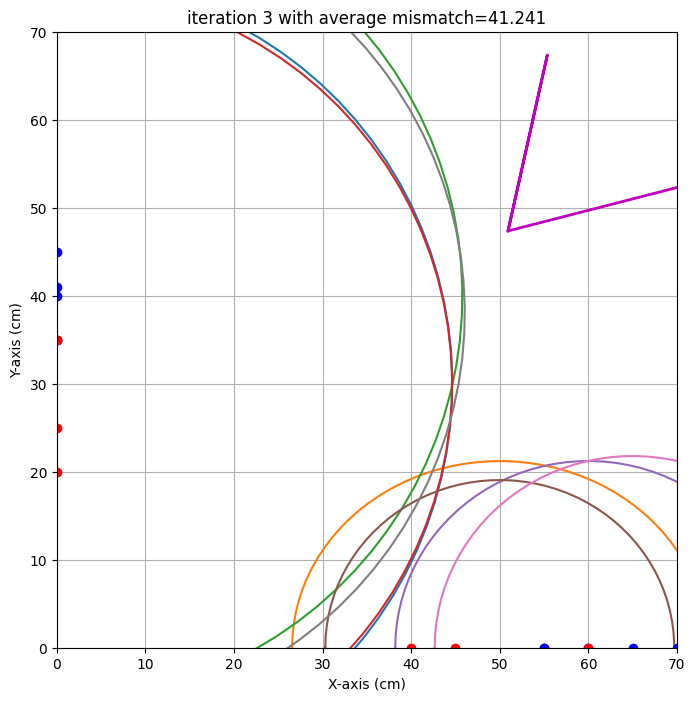

end iteration 3 with average mismatch=41.241


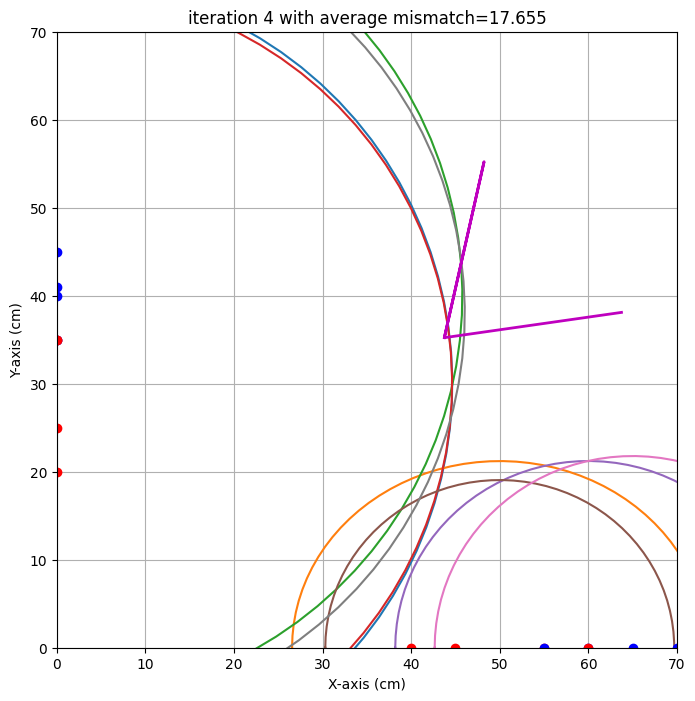

end iteration 4 with average mismatch=17.655


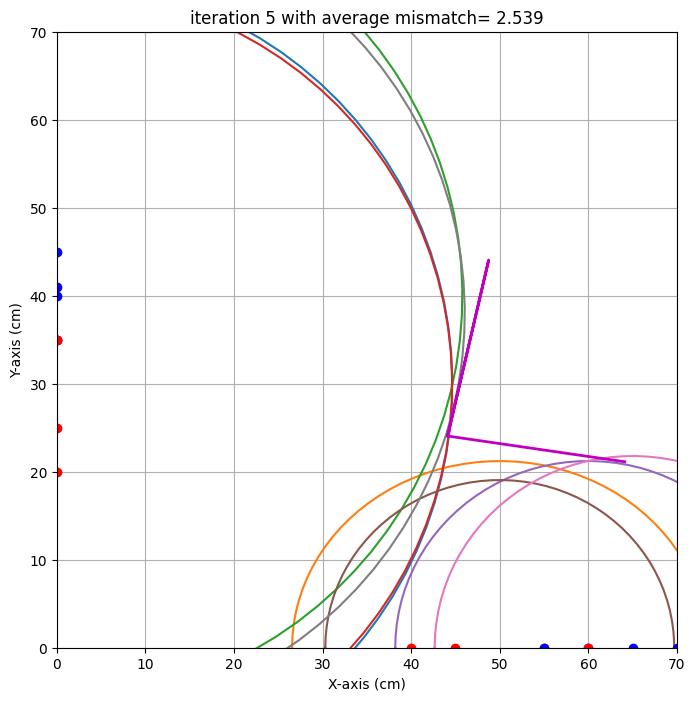

end iteration 5 with average mismatch= 2.539


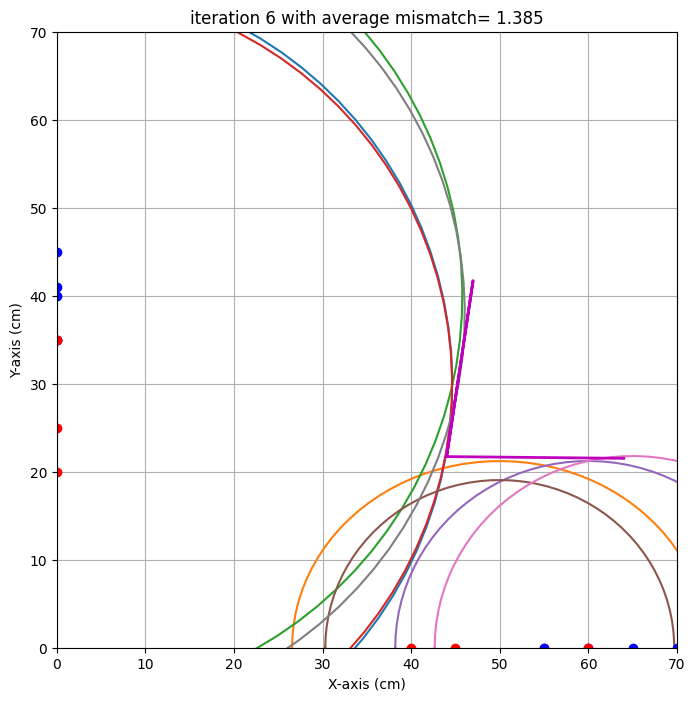

end iteration 6 with average mismatch= 1.385
end iteration 7 with average mismatch= 1.250
end iteration 8 with average mismatch= 1.155


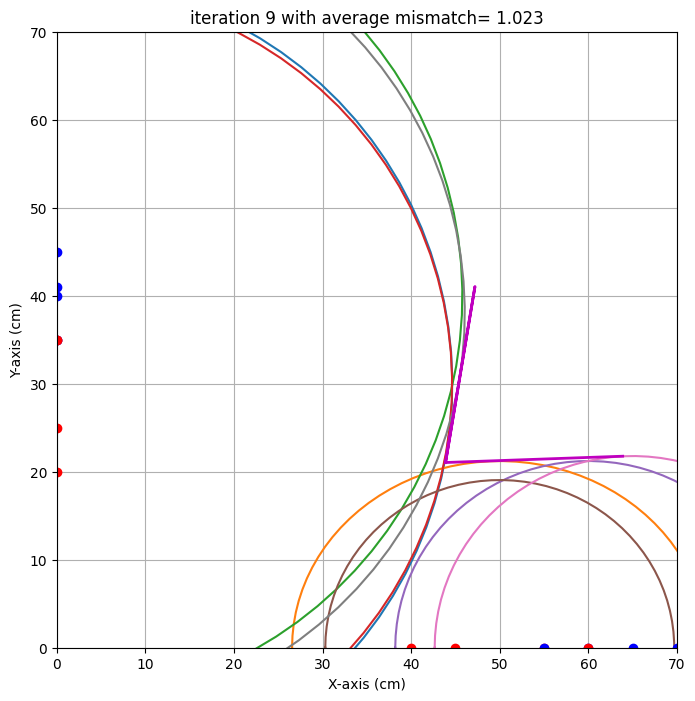

end iteration 9 with average mismatch= 1.023
end iteration 10 with average mismatch= 1.006
end iteration 11 with average mismatch= 0.998
end iteration 12 with average mismatch= 0.996
end iteration 13 with average mismatch= 0.995
end iteration 14 with average mismatch= 0.995
end iteration 15 with average mismatch= 0.995
end iteration 16 with average mismatch= 0.995
end iteration 17 with average mismatch= 0.995
end iteration 18 with average mismatch= 0.995
end iteration 19 with average mismatch= 0.995
end iteration 20 with average mismatch= 0.995
end iteration 21 with average mismatch= 0.995
end iteration 22 with average mismatch= 0.995
end iteration 23 with average mismatch= 0.995
end iteration 24 with average mismatch= 0.995
end iteration 25 with average mismatch= 0.995
end iteration 26 with average mismatch= 0.995
end iteration 27 with average mismatch= 0.995
end iteration 28 with average mismatch= 0.995
end iteration 29 with average mismatch= 0.995
Last iteration, also determine unce

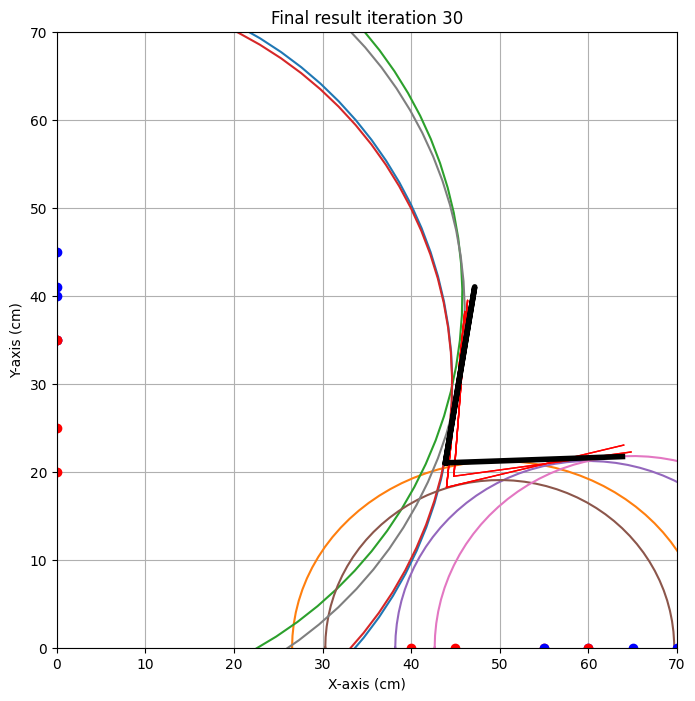

{'alpha': np.float64(2.0387792389298527), 'alpha_eps': np.float64(11.459943975708878), 'beta': np.float64(9.43086706258839), 'beta_eps': np.float64(5.0029649194871935), 'x0': np.float64(43.85051932388536), 'x0_eps': np.float64(0.969787732109026), 'y0': np.float64(21.00875633126707), 'y0_eps': np.float64(2.784532280703054)}
locatie 1 
x0 target is : 30.0. Gevonden waarde: 31.8 cm met een standaardafwijking van 0.7 cm 
y0 target is : 46.0. Gevonden waarde: 46.3 cm met een standaardafwijking van 0.4 cm 
alpha target is : 30.0. Gevonden waarde: 19.1 graden met een standaardafwijking van 1.5 graad 
beta target is : 10.0. Gevonden waarde: 2.9 graden met een standaardafwijking van 5.7 graad 

locatie 2 
x0 target is : 44.0. Gevonden waarde: 43.9 cm met een standaardafwijking van 1.0 cm 
y0 target is : 16.0. Gevonden waarde: 21.0 cm met een standaardafwijking van 2.8 cm 
alpha target is : 14.0. Gevonden waarde: 2.0 graden met een standaardafwijking van 11.5 graad 
beta target is : 10.0. Gevond

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':30,
                    'y0':46,
                    'alpha' : 30,
                    'beta' : 10},
           'locatie 2':{'x0':44,
                    'y0':16,
                    'alpha' :14,
                    'beta' : 10}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,60,68.5],
    #[0,20,0,40,ongeldig],
    [40,0,60,0,100.7],
    #[20,0,40,0,ongeldig],
    [45,0,55,0,99.8],
    #[35,0,45,0,ongeldig],
    [0,45,0,55,64.2],
    [0,55,0,65,64.3],
    [0,60,0,70,66.1],
    [35,0,45,0,122.0],
    [50,0,60,0,106.8],
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,20,0,40,91.5],
    [40,0,60,0,46.9],
    [0,35,0,45,92.1],
    [0,25,0,35,89.8],
    [55,0,65,0,43.6],
    [45,0,55,0,39.4],
    [60,0,70,0,44.7],
    [0,35,0,41,92.3],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  60  62.2
1   0  20   0  40  62.0
2  20   0  40   0  55.0
3   0  40   0  50  58.4
4   0  30   0  40  59.0
5  30   0  40   0  48.3
6  20   0  30   0  52.7


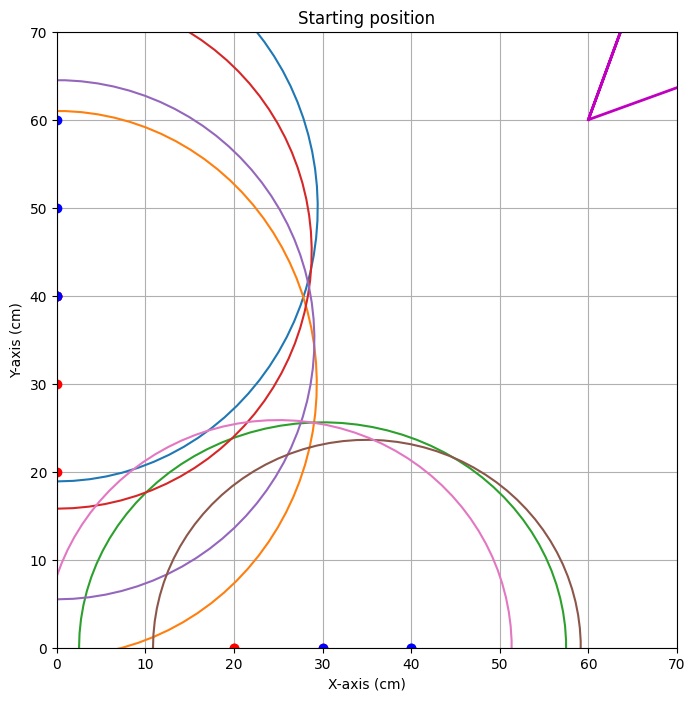


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=80.576


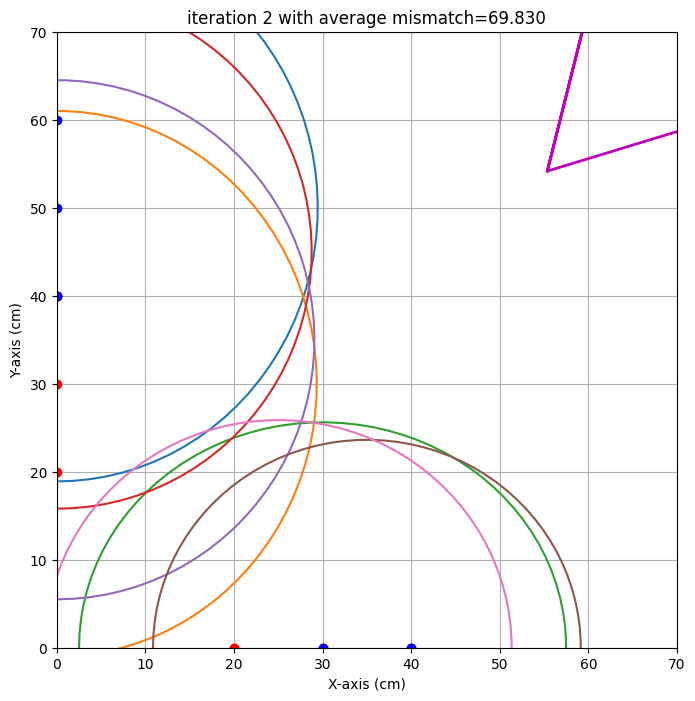

end iteration 2 with average mismatch=69.830


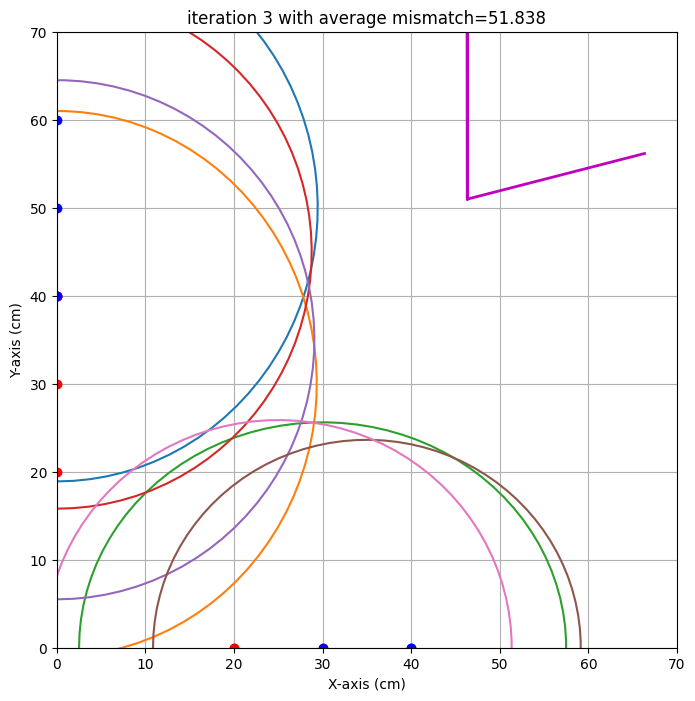

end iteration 3 with average mismatch=51.838


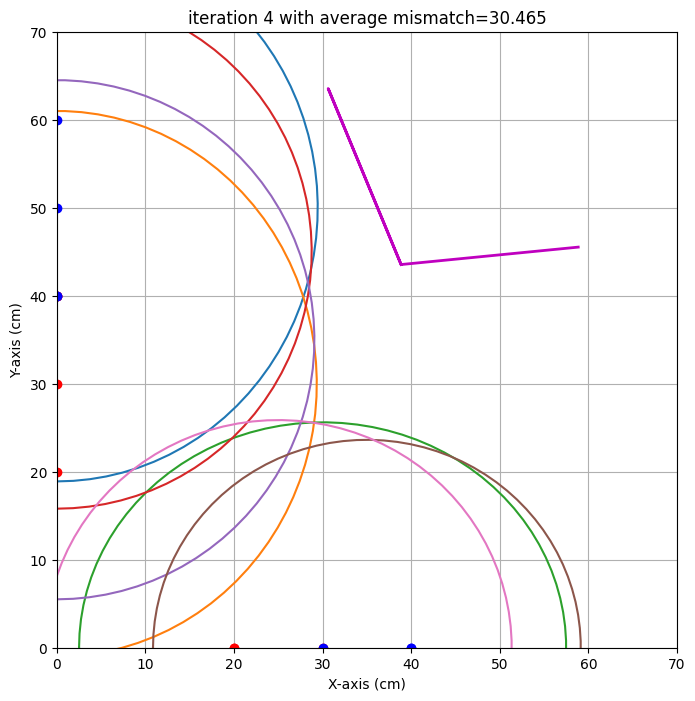

end iteration 4 with average mismatch=30.465


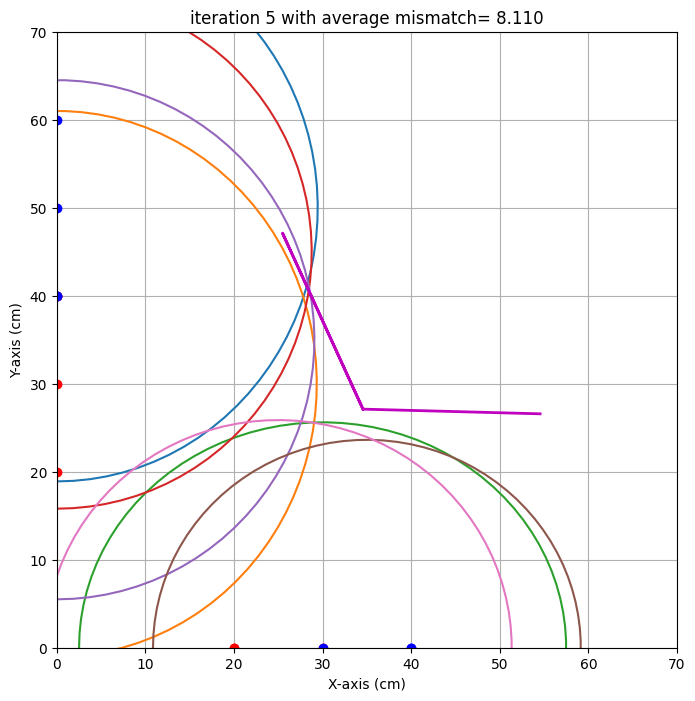

end iteration 5 with average mismatch= 8.110


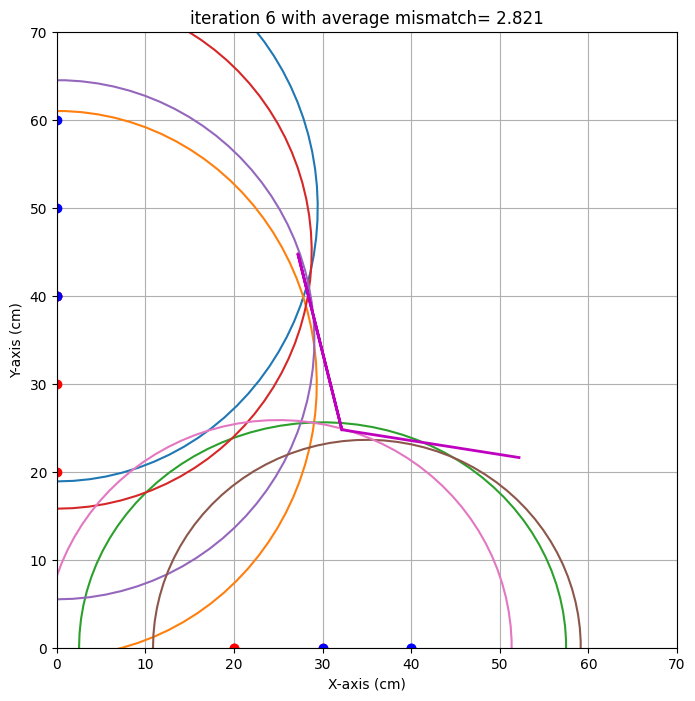

end iteration 6 with average mismatch= 2.821


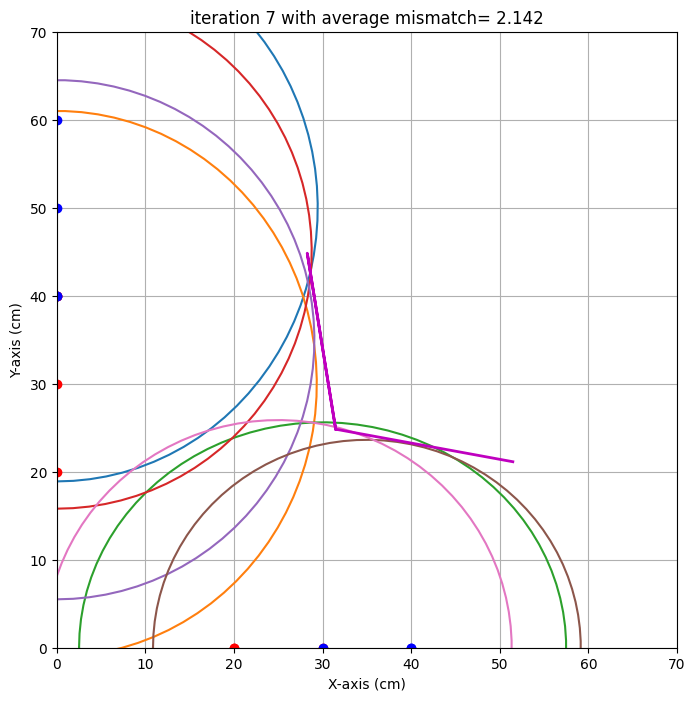

end iteration 7 with average mismatch= 2.142


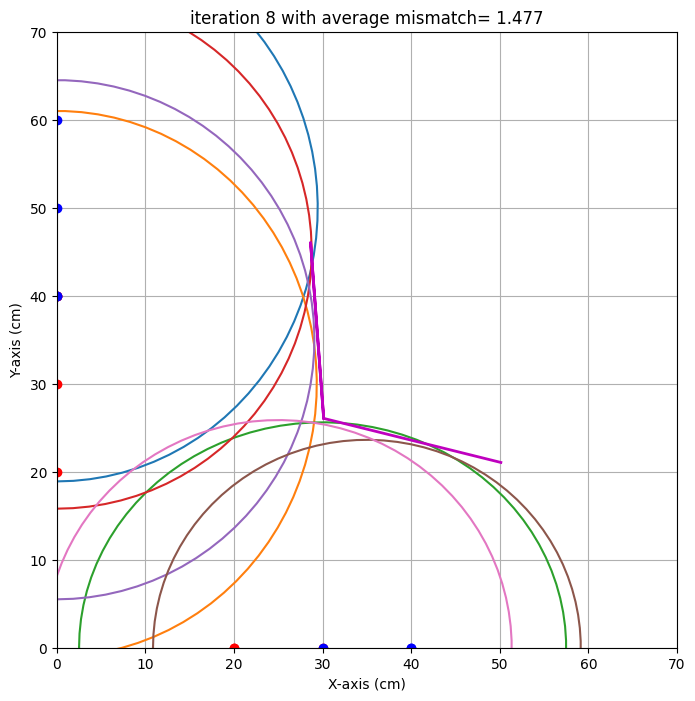

end iteration 8 with average mismatch= 1.477


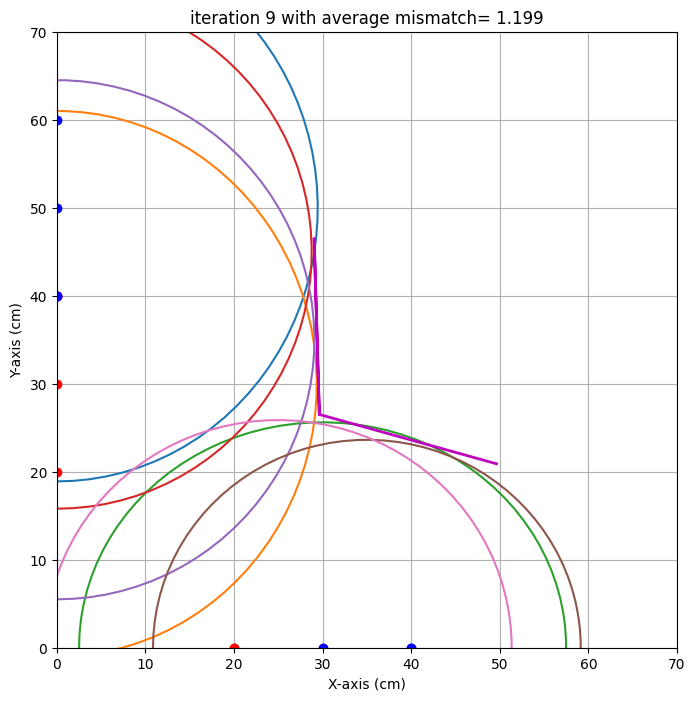

end iteration 9 with average mismatch= 1.199
end iteration 10 with average mismatch= 1.116
end iteration 11 with average mismatch= 1.096
end iteration 12 with average mismatch= 1.084
end iteration 13 with average mismatch= 1.084
end iteration 14 with average mismatch= 1.084
end iteration 15 with average mismatch= 1.084
end iteration 16 with average mismatch= 1.084
end iteration 17 with average mismatch= 1.084
end iteration 18 with average mismatch= 1.083
end iteration 19 with average mismatch= 1.063
end iteration 20 with average mismatch= 1.024
end iteration 21 with average mismatch= 1.022
end iteration 22 with average mismatch= 1.021
end iteration 23 with average mismatch= 1.021
end iteration 24 with average mismatch= 1.021
end iteration 25 with average mismatch= 1.021
end iteration 26 with average mismatch= 1.021
end iteration 27 with average mismatch= 1.021
end iteration 28 with average mismatch= 1.021
end iteration 29 with average mismatch= 1.021
Last iteration, also determine unce

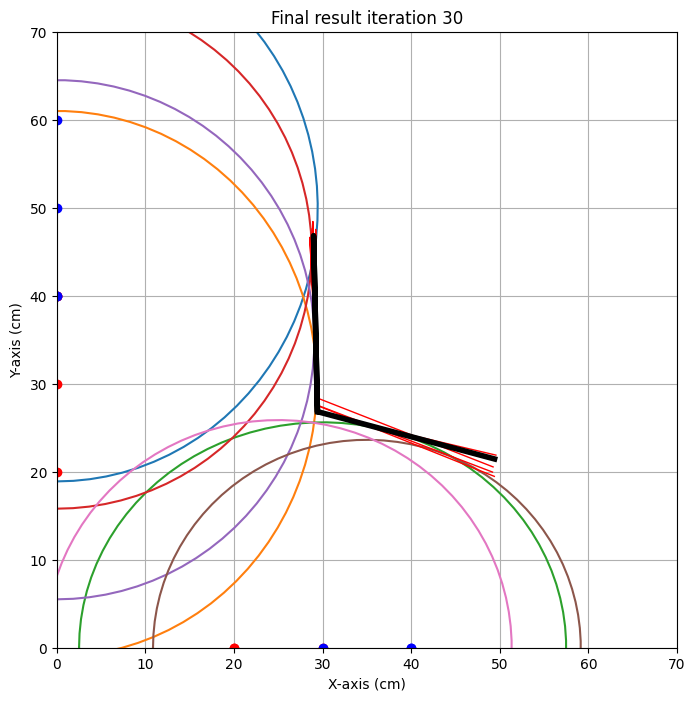

{'alpha': np.float64(-15.055550147258746), 'alpha_eps': np.float64(6.892432912420787), 'beta': np.float64(-1.235182594153514), 'beta_eps': np.float64(1.6625771270408363), 'x0': np.float64(29.41279450306264), 'x0_eps': np.float64(0.23103101849002883), 'y0': np.float64(26.829072404702725), 'y0_eps': np.float64(1.6066309822240825)}
test locatie 
x0 target is : 29.0. Gevonden waarde: 29.4 cm met een standaardafwijking van 0.2 cm 
y0 target is : 27.0. Gevonden waarde: 26.8 cm met een standaardafwijking van 1.6 cm 
alpha target is : -3.0. Gevonden waarde: -15.1 graden met een standaardafwijking van 6.9 graad 
beta target is : -5.0. Gevonden waarde: -1.2 graden met een standaardafwijking van 1.7 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
#targets = {'test locatie':{
                    #'x0':  41,
                    #'y0':  41,
                    #'alpha' :  -9,
                    #'beta' :  -4
                          #}
            #}
           
targets = {'test locatie':{
                    'x0':  29,
                    'y0':  27,
                    'alpha' : -3 ,
                    'beta' :  -5
                          }
            }

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

#dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                #[0,40,0,60,80.8],
                #[0,20,0,40,ongeldig]
                #[40,0,60,0,78.6],
                #[20,0,40,0,91.1],
                #[0,50,0,60,77.7],
                #[0,45,0,55,78.9],
                #[50,0,60,0,76.9],
                #[45,0,55,0,77.4],
                #[0,55,0,65,80.4],
                #[57,0,63,0,77.1],
                    #])
                #}

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                [0,40,0,60,62.2],
                [0,20,0,40,62.0],
                #[40,0,60,0,ongeldig]
                [20,0,40,0,55.0],
                [0,40,0,50,58.4],
                [0,30,0,40,59.0],
                [30,0,40,0,48.3],
                [20,0,30,0,52.7],

                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.


Eerst zijn drie verschillende algoritmes gemaakt. Vervolgens zijn twee hiervaan getest, waarvan fouten zijn aangepakt, aangepast en verbeterd.

<img src="algoritme_avnay_1.jpeg" width="400">
<img src="algoritme_avnay_2.jpeg" width="400">


<img src="algoritme_aren_2.jpeg" width="400">


<img src="algoritme_koen_1.jpeg" width="400">
<img src="algoritme_koen_2.jpeg" width="400">


Vervolgens zijn de ideeen van de voorgaande algoritmes samengevoegd tot een algoritme. Dit algoritme is uiteindelijk gebruikt voor de eindopdracht.
Figuur: ![Alt](iteratie1.jpeg)